# Repaired reproducibility version

Derived from the original supplementary notebook. Original plotting/analysis cells are retained; only documented path, environment, missing-helper and unambiguous stale-variable fixes were applied. See `../REPAIR_LOG.md` for every change and items requiring manual confirmation.

In [1]:
source('../shared/r_funcs_repro.r')

# figure s2 vlz

- kernel: r_env, R 4.1.3
- date: 2024-03-04

## load

In [2]:
library(tidyverse)
library(tools)
library(logging)
library(ggpubr)
library(ggsci)
library(patchwork)
library(igraph)
library(ggraph)
library(Seurat)
library(ComplexHeatmap)

source('../shared/r_funcs_repro.r')

theme_set(theme_pubr())
logging::basicConfig()
options(warn = -1)

outdir <- '../../output/figs2'
create_dir(outdir)

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ purrr     1.1.0
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘igraph’


The following objects are masked from ‘package:lubridate’:

    %--%, union


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘pa

In [3]:
f_pat_gp <- '../../data/tables/patient_info_v2.tsv'
gp <- 'response'

gp_comp_map$response <- list(
  c('R-pre', 'R-post'),
  c('NR-pre', 'NR-post'),
  c('R-pre', 'NR-pre'),
  c('R-post', 'NR-post')
)
gp_lvls$response <- c('R', 'NR')
comb_order <- c('R-pre', 'R-post', 'NR-pre', 'NR-post')

## s2a: signature contribution

In [4]:
f_contri <- '../../data/stage4/a11_wes/new-muts/signature/signatue-contribution.tsv'

In [5]:
df <- read_tsv(f_contri, show_col_types = F) %>% 
    select(-c('patient', 'mandard_group', 'treatment_group')) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient_id')
df %>% head(2)

2026-07-18 17:01:56.807681 INFO::these clinial info will be added: response


,patient_id,response,sample,sample_type,sig_name,aetiology,best_match,cosmic_name,prop,sig_cat
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
1,006,R,01-006-T,Baseline,Signature_8,Unknown,Best match: SBS5 [cosine-similarity: 0.745],SBS5,6.928890e-16,SBS5
2,006,R,01-006-T,Baseline,Signature_2,defective DNA mismatch repair,Best match: SBS6 [cosine-similarity: 0.608],SBS6,5.514562e-11,SBS6


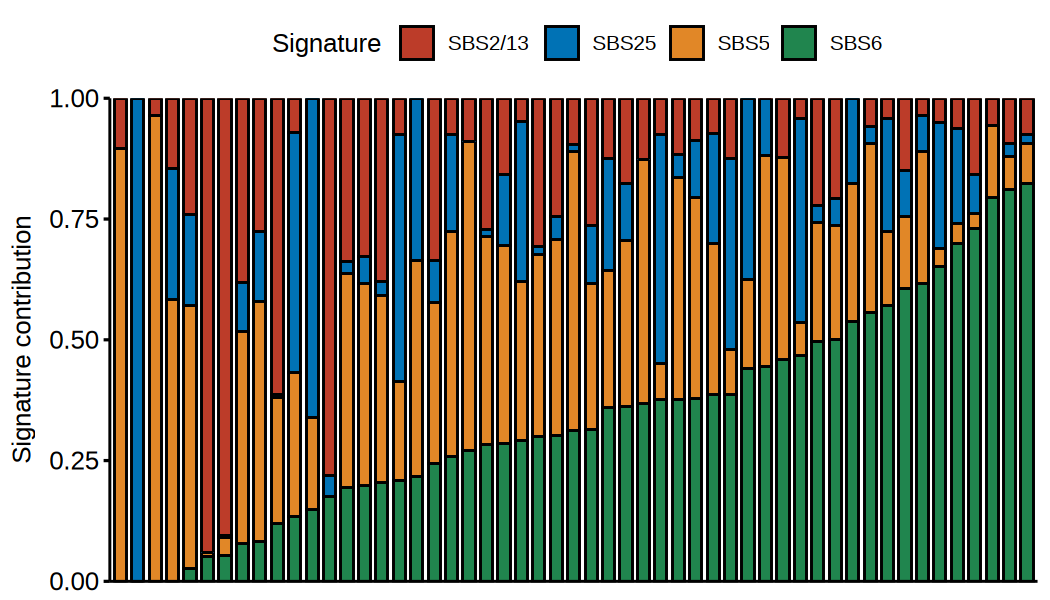

In [6]:
# summarise data
dp <- summarise(df, .by = c('sample', 'sig_cat'), prop = sum(prop))

dp %>% write_tsv(str_glue('{outdir}/figs2a-signature_contribution.tsv'))

# order sample by SBS6
samp_order <- dp %>%
filter(sig_cat == 'SBS6') %>%
arrange(prop) %>%
pull(sample) %>%
unique()

# plot
p <- dp %>% 
    mutate(sig_cat = factor(sig_cat, sort(unique(sig_cat))),
           sample = factor(sample, samp_order)) %>%
    ggbarplot(x = 'sample', y = 'prop', fill = 'sig_cat', position = position_fill(), palette = 'nejm') +
    scale_y_continuous(expand = c(0, NA)) +
    labs(y = 'Signature contribution', fill = 'Signature') +
    theme(axis.text.x = element_blank(), axis.title.x = element_blank(), axis.ticks.x = element_blank(), 
          legend.title = element_text(vjust = 0.5, hjust = 0.5))
ggsave(filename = str_glue('{outdir}/figs2a-bar-signature_contribute.pdf'), plot = p, width = 7, height = 4)
jp_opt(wd = 7, hg = 4)
print(p)


## s2b: TMB boxplot

- TMB: based on T-N paired, fresh, non-LN samples; mutation based on pyclone results (t_alt_count >= 3, t_depth >= 30, autosome mutations)

In [ ]:
f_tmb <- '../../data/tables/tmb-tn_pair.tsv'
target_size_mb <- 38  # target exome size in megabases

tmb <- read_tsv(f_tmb, show_col_types = F)
loginfo('%g mutations, %g samples', sum(tmb$n_mutation), length(unique(tmb$sample_id)))

2025-12-17 08:51:21.988421 INFO::7994 mutations, 73 samples


In [ ]:
# sample filtering
tmb_flt <- tmb %>% 
  filter(
    pair_cat == 'Fresh',
    !grepl('-LN', sample_id),
    sample_type == 'Baseline',
    !is.na(mandard_group)
  ) %>%
  mutate(
    response = factor(case_match(mandard_group, 'good' ~ 'R', 'poor' ~ 'NR'), levels = c('R', 'NR')),
    TMB = n_mutation / (target_size_mb)
  )

loginfo('tn-pair, fresh, non-LN, pre: %g mutations, %g samples', sum(tmb_flt$n_mutation), length(unique(tmb_flt$sample_id)))
tmb_flt %>% 
  select(patient_id, response) %>% 
  unique() %>% 
  count(response)

2025-12-17 08:54:00.793106 INFO::tn-pair, fresh, non-LN, pre: 5099 mutations, 41 samples


response,n
<fct>,<int>
R,27
NR,14


In [ ]:
# pre: R vs NR
p <- tmb_flt %>% 
    cell_comp_boxplot(x = 'response', y = 'TMB', xorder = NULL,
                      pt_fill = 'response', fill_order = NULL, pair_by = NULL,
                      facet_by = NULL, ytitle = 'TMB') +
    scale_y_continuous(trans = 'log10') + 
    stat_compare_means(comparisons = list(c('R', 'NR'))) +
    labs(fill = '', x = '', y = 'TMB (Mutations/Mb)', title = 'TMB of Pre-Treatment Samples') 
p

Warning message in wilcox.test.default(c(1.18439253577352, 0.754670154534121, -0.048304679574555, :
"cannot compute exact p-value with ties"
